<h1>Load Data</h1>

In [6]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from pathlib import Path
import itertools
import os
import shutil
import random
import glob
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

random.seed(42)
# For reproducibility across PyTorch as well
try:
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)
except Exception as e:
    print("Warning: could not set PyTorch seed:", e)

#Organize data into train, test and validation sets
notebook_dir = Path.cwd() #get current notebook dir

data_folder = notebook_dir.parent / "data" #create path to data folder

os.chdir(data_folder)

#create folders inside data
dirs = [
    "train/dog", "train/cat",
    "valid/dog", "valid/cat",
    "test/dog",  "test/cat"
]

for d in dirs:
    (data_folder / d).mkdir(parents=True, exist_ok=True)


#Base folders
target_folders = ["train", "valid", "test"]

#Create target folders if they don't exist
for split in target_folders:
    for cls in ["cat", "dog"]:
        folder = data_folder / split / cls
        folder.mkdir(parents=True, exist_ok=True)

#Source folders
cat_src = data_folder / "Cat"
dog_src = data_folder / "Dog"

#Function to move images randomly
def move_images(src_folder, dst_folder, n):
    imgs = list(src_folder.glob("*.jpg"))
    if not imgs:
        print(f"Warning: No images found in {src_folder}")
        return
    k = min(n, len(imgs))
    if k < n:
        print(f"Requested {n} images from {src_folder}, but only {len(imgs)} available. Sampling {k}.")
    sampled = random.sample(imgs, k)
    for img_path in sampled:
        shutil.copy2(str(img_path), dst_folder)

#Move images
move_images(cat_src, data_folder / "train" / "cat", 500)
move_images(dog_src, data_folder / "train" / "dog", 500)
move_images(cat_src, data_folder / "valid" / "cat", 100)
move_images(dog_src, data_folder / "valid" / "dog", 100)
move_images(cat_src, data_folder / "test" / "cat", 100)
move_images(dog_src, data_folder / "test" / "dog", 100)

<h3>Look at some images of the dataset</h3>

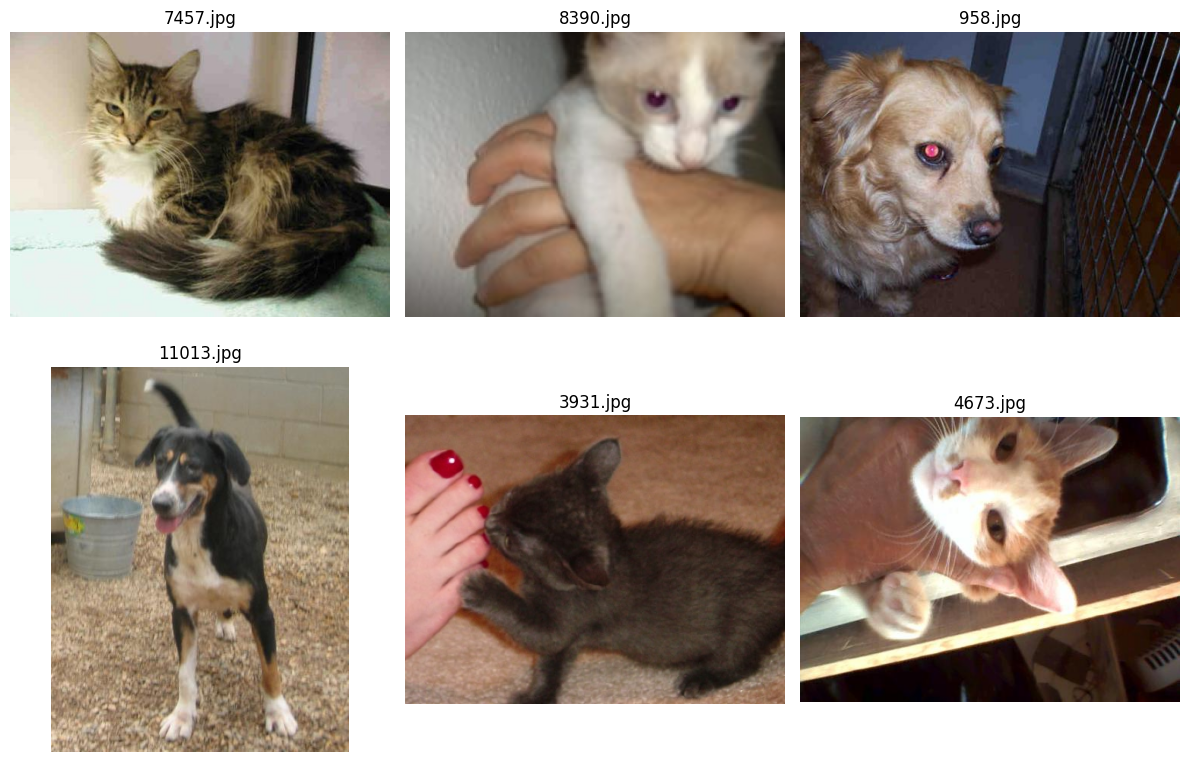

In [7]:
import pandas as pd
from PIL import Image
import imagesize

root = "../data/"

imgs = [img for img in Path(root).rglob("*.jpg")] #get all images from the subfolders

sampled = random.sample(imgs, 6)

plt.figure(figsize=(12, 8)) 
for i, filename in enumerate(sampled, 1):
     img_path = Path(root) / filename 
     img = Image.open(img_path) 
     plt.subplot(2, 3, i) 
     plt.imshow(img) 
     plt.axis("off") 
     plt.title(img_path.name) 
plt.tight_layout() 
plt.show()

Visualizing image sizes
<p>Before we resize the images we check out the datasets qualities.
<ul>
    <li>Size</li>
    <li>Width</li>
    <li>Height</li>
</ul>


In [8]:
sampled_imgs = random.sample(imgs, 3000)
img_meta = {}
for f in sampled_imgs: 
    img_meta[str(f)] = imagesize.get(f)  #Here we get the images resolution (f represents one image it is a path object)

#Convert into dataframe
img_meta_df = pd.DataFrame.from_dict([img_meta]).T.reset_index().set_axis(['FileName', 'Size'], axis='columns')
img_meta_df[["Width", "Height"]] = pd.DataFrame(img_meta_df["Size"].tolist(), index=img_meta_df.index)
img_meta_df["Aspect Ratio"] = round(img_meta_df["Width"] / img_meta_df["Height"], 2)

print(f'Total Nr of Images in the dataset: {len(img_meta_df)}')
img_meta_df.head()


Total Nr of Images in the dataset: 3000


,FileName,Size,Width,Height,Aspect Ratio
0,..\data\Cat\2649.jpg,"(375, 500)",375,500,0.75
1,..\data\train\dog\1807.jpg,"(367, 500)",367,500,0.73
2,..\data\Dog\3427.jpg,"(500, 387)",500,387,1.29
3,..\data\Cat\9547.jpg,"(500, 375)",500,375,1.33
4,..\data\Dog\3172.jpg,"(500, 411)",500,411,1.22


Text(0, 0.5, 'Height')

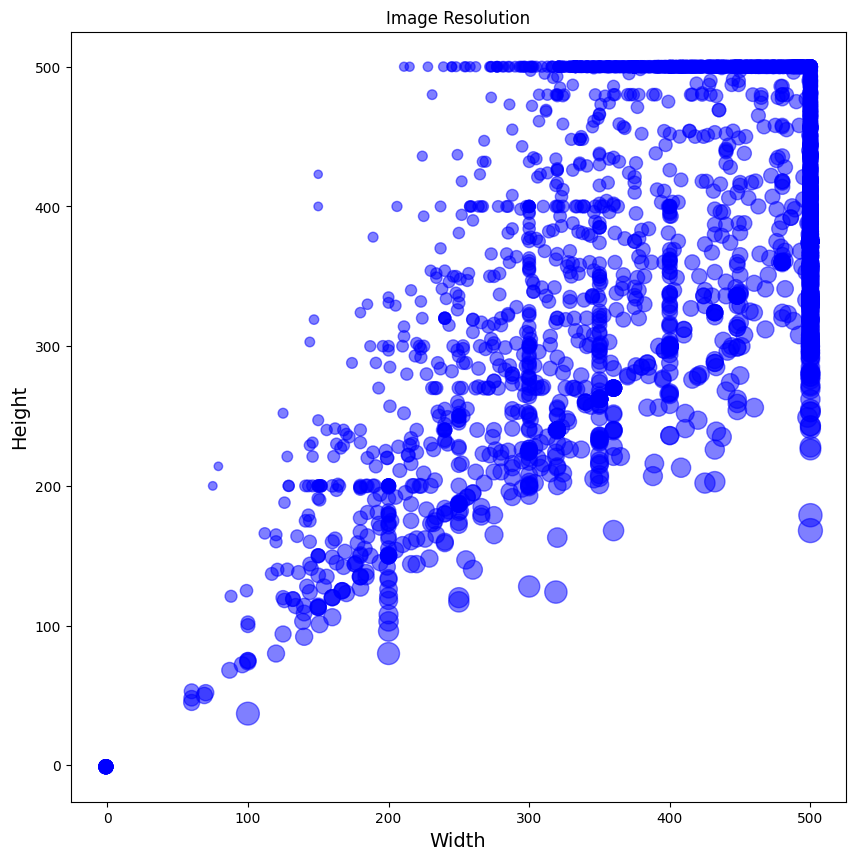

In [9]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
points = ax.scatter(img_meta_df.Width, img_meta_df.Height, color='blue', alpha=0.5, s=img_meta_df["Aspect Ratio"]*100, picker=True)
ax.set_title("Image Resolution")
ax.set_xlabel("Width", size=14)
ax.set_ylabel("Height", size=14)

These results show us that many of the images have a quadratic form. And we can resize them without (much) cropping or padding.

<h3>Greyscale pixel intensity histogram across dataset</h3>
<p>50 sampled images; 0=black, 255=white; it seems to be a normal distribution without missing ranges


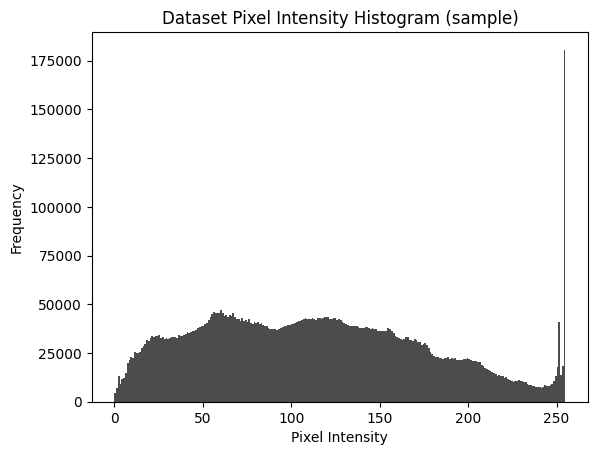

In [10]:
imgs = random.sample(imgs, 50)

all_pixels = []

for img_path in imgs:
    img = Image.open(img_path).convert("L")
    pixels = np.array(img).flatten()
    all_pixels.extend(pixels)

plt.hist(all_pixels, bins=256, range=(0, 255), color='black', alpha=0.7)
plt.title("Dataset Pixel Intensity Histogram (sample)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()


Preprocessing pipeline with PyTorch
<p>Images are resized/cropped to 224x224. Augmentations are applied to the training set only. 

Classes: ['cat', 'dog']
Class to index: {'cat': 0, 'dog': 1}
Train/Valid/Test sizes: 1000/200/200
Batch tensor shape: torch.Size([32, 3, 224, 224])


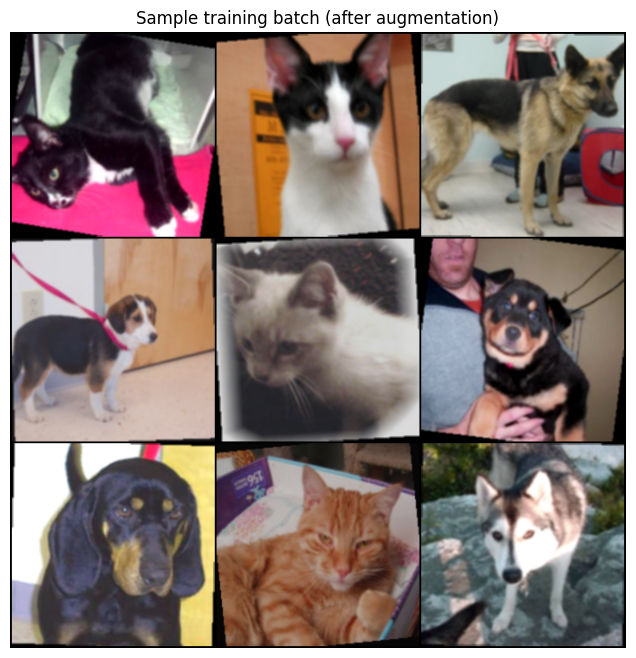

In [11]:
from torchvision.transforms import InterpolationMode

batch_size = 32
img_size = 224

# Normalization (ImageNet stats work well for RGB natural images)
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# Data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BILINEAR),
    transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0), ratio=(0.9, 1.1), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10, interpolation=InterpolationMode.BILINEAR),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    normalize,
])

# Validation/Test: no augmentation, deterministic
inference_transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    normalize,
])

# Datasets
train_dir = data_folder / "train"
valid_dir = data_folder / "valid"
test_dir  = data_folder / "test"

train_ds = datasets.ImageFolder(str(train_dir), transform=train_transform)
valid_ds = datasets.ImageFolder(str(valid_dir), transform=inference_transform)
test_ds  = datasets.ImageFolder(str(test_dir),  transform=inference_transform)

# DataLoaders
num_workers = 2  # adjust based on CPU cores
pin_memory = True if torch.cuda.is_available() else False

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=pin_memory)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

print("Classes:", train_ds.classes)
print("Class to index:", train_ds.class_to_idx)
print(f"Train/Valid/Test sizes: {len(train_ds)}/{len(valid_ds)}/{len(test_ds)}")

# Visualize a training batch
images, labels = next(iter(train_loader))
print("Batch tensor shape:", images.shape)

# Convert back to [0,1] for display from normalized tensors
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)

imgs_show = inv_normalize(images.clone())
grid = make_grid(imgs_show[:9], nrow=3, padding=2)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Sample training batch (after augmentation)")
plt.show()


<h3>Preprocessing adequacy check</h3>
<p>
The current PyTorch preprocessing is appropriate for a Cats vs Dogs CNN:
</p>
<ul>
<li>Deterministic validation/test pipeline: Resize(256) -> CenterCrop(224) -> ToTensor -> Normalize.</li>
<li>Training-time augmentation: RandomResizedCrop, HorizontalFlip, small Rotation, ColorJitter, and GaussianBlur. These improve generalization without changing labels.</li>
<li>Normalization: ImageNet mean/std, which is standard for RGB natural images. Alternatively, you can compute dataset-specific stats later.</li>
<li>Batch visualization included to sanity-check augmentations and labels.</li>
</ul>
<p>
If you want to preserve aspect ratios even more aggressively, you can swap RandomResizedCrop for Resize(256) + CenterCrop(224), or add a small reflect Pad before crops. For now, RandomResizedCrop provides good invariance and works well in practice.
</p>